---

#  Dataset Overview 

###  Problem Type:

* **Regression Task**
* Goal: Predict the **product demand** (`Demand`) based on sales and store/product conditions.

---

##  General Information

| Attribute          | Detail                                         |
| ------------------ | ---------------------------------------------- |
| Rows            | \~76,000                                       |
| Initial Columns | 12 (before feature engineering)                |
| Final Features   | \~23+ (after encoding & engineering)           |
| Target Variable | `Demand` (units of product demanded)           |
| Time Feature    | Contains `Date`, but not used as a time series |

---

##  Feature Descriptions

| Column Name       | Description                                         |
| ----------------- | --------------------------------------------------- |
| `Date`            | The date of the sale transaction                    |
| `Store ID`        | Unique identifier of the store                      |
| `Product ID`      | Unique identifier of the product                    |
| `Units Sold`      | Number of product units sold                        |
| `Units Ordered`   | Number of product units ordered                     |
| `Inventory Level` | Stock quantity available at time of sale            |
| `Price`           | Unit price of the product                           |
| `Discount`        | Discount amount applied (if any)                    |
| `Promotion`       | Whether the item was promoted (boolean)             |
| `Holiday`         | Whether the sale happened on a holiday (boolean)    |
| `Weather`         | If the weather was favorable for shopping (boolean) |
| `Weekday`         | Whether the day was a weekday (boolean)             |
| `Weekend`         | Whether the day was a weekend (boolean)             |
| `Holiday_Week`    | Whether it was within a holiday week (boolean)      |
| `Special_Event`   | If any special event was ongoing (boolean)          |
| `Demand`          | Target variable: product demand                  |

---

##  Engineered Features (Created Manually)

| New Feature     | Description                                      |
| --------------- | ------------------------------------------------ |
| `Sold_Percent`  | Proportion of units sold to units ordered        |
| `Revenue`       | Total revenue = Units Sold × Price               |
| `Is_Discounted` | Flag indicating if discount was applied (0 or 1) |
| `Stock_Change`  | Difference between inventory and units sold      |

---

# Data Access and Initial Overview

## Import required libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import warnings
warnings.filterwarnings("ignore")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2025-06-02 23:28:58.126179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748906938.394497      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748906938.471027      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/retail-store-inventory-and-demand-forecasting/sales_data.csv


## Load the dataset

In [2]:
df = pd.read_csv("/kaggle/input/retail-store-inventory-and-demand-forecasting/sales_data.csv")

## Check shape, data types, and basic stats

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [5]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [6]:
df.describe(include='all')

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
count,76000,76000,76000,76000,76000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000,76000.000000,76000.000000,76000,76000.000000,76000.000000
unique,760,5,20,5,4,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,4,NaN,NaN
top,2022-01-01,S001,P0001,Groceries,North,NaN,NaN,NaN,NaN,NaN,Cloudy,NaN,NaN,Winter,NaN,NaN
freq,100,15200,3800,30400,30400,NaN,NaN,NaN,NaN,NaN,24360,NaN,NaN,21000,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,301.062842,88.827316,89.090645,67.726028,9.087039,NaN,0.328947,69.454029,NaN,0.200000,104.317158
std,NaN,NaN,NaN,NaN,NaN,226.510161,43.994525,162.404627,39.377899,7.475781,NaN,0.469834,40.943818,NaN,0.400003,46.964801
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,4.740000,0.000000,NaN,0.000000,4.290000,NaN,0.000000,4.000000
25%,NaN,NaN,NaN,NaN,NaN,136.000000,58.000000,0.000000,31.997500,5.000000,NaN,0.000000,32.620000,NaN,0.000000,71.000000
50%,NaN,NaN,NaN,NaN,NaN,227.000000,84.000000,0.000000,64.500000,10.000000,NaN,0.000000,65.700000,NaN,0.000000,100.000000
75%,NaN,NaN,NaN,NaN,NaN,408.000000,114.000000,121.000000,95.830000,10.000000,NaN,1.000000,97.932500,NaN,0.000000,133.000000


In [7]:
df.nunique()

Date                    760
Store ID                  5
Product ID               20
Category                  5
Region                    4
Inventory Level        1426
Units Sold              330
Units Ordered           996
Price                 15396
Discount                  6
Weather Condition         4
Promotion                 2
Competitor Pricing    15963
Seasonality               4
Epidemic                  2
Demand                  340
dtype: int64

## Check for missing values

## Target variable distribution

In [8]:
df['Demand'].value_counts()

Demand
88     743
102    732
100    723
103    722
90     704
      ... 
347      1
335      1
301      1
339      1
370      1
Name: count, Length: 340, dtype: int64

## Data Dictionary 

In [9]:
data_dictionary = {
    "Date": "Transaction date",
    "Store ID": "Unique identifier for store",
    "Product ID": "Unique identifier for product",
    "Category": "Product category",
    "Region": "Sales region",
    "Inventory Level": "Number of items in stock",
    "Units Sold": "Items sold to customers",
    "Units Ordered": "Items ordered (customer demand)",
    "Price": "Selling price per unit",
    "Discount": "Discount rate applied (%)",
    "Weather Condition": "Weather during the transaction",
    "Promotion": "Was a promotion active? (1=yes, 0=no)",
    "Competitor Pricing": "Price of the product at competitors",
    "Seasonality": "Season of the year (e.g., Winter, Spring)",
    "Epidemic": "Epidemic present? (1=yes, 0=no)",
    "Demand": "Final demand (target variable)"
}
print("\n🔹 Data Dictionary:")
for feature, description in data_dictionary.items():
    print(f"{feature:20} : {description}")


🔹 Data Dictionary:
Date                 : Transaction date
Store ID             : Unique identifier for store
Product ID           : Unique identifier for product
Category             : Product category
Region               : Sales region
Inventory Level      : Number of items in stock
Units Sold           : Items sold to customers
Units Ordered        : Items ordered (customer demand)
Price                : Selling price per unit
Discount             : Discount rate applied (%)
Weather Condition    : Weather during the transaction
Promotion            : Was a promotion active? (1=yes, 0=no)
Competitor Pricing   : Price of the product at competitors
Seasonality          : Season of the year (e.g., Winter, Spring)
Epidemic             : Epidemic present? (1=yes, 0=no)
Demand               : Final demand (target variable)


# Data Cleaning and Transformation

## Use mean imputation as an example

In [10]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

## Detect and remove outliers using IQR method

In [11]:
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]


## Apply to selected numeric columns

In [12]:
outlier_columns = ['Units Sold', 'Units Ordered', 'Price', 'Discount', 'Competitor Pricing', 'Demand']
for col in outlier_columns:
    df = remove_outliers_iqr(df, col)

## Drop irrelevant columns (IDs)

In [13]:
df.drop(columns=['Store ID', 'Product ID'], inplace=True)

## Convert data types

In [14]:
df['Date'] = pd.to_datetime(df['Date'])  # Convert to datetime
categorical_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality']
for col in categorical_cols:
    df[col] = df[col].astype('category')

## Binary columns can be left as is if they’re already 0/1

In [15]:
df['Promotion'] = df['Promotion'].astype(int)
df['Epidemic'] = df['Epidemic'].astype(int)


## One-hot encode categorical variables

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [17]:
print(f"✅ Cleaned and encoded dataset shape: {df_encoded.shape}")

✅ Cleaned and encoded dataset shape: (56919, 23)


# Exploratory Data Analysis (EDA)

## Distribution of numerical features

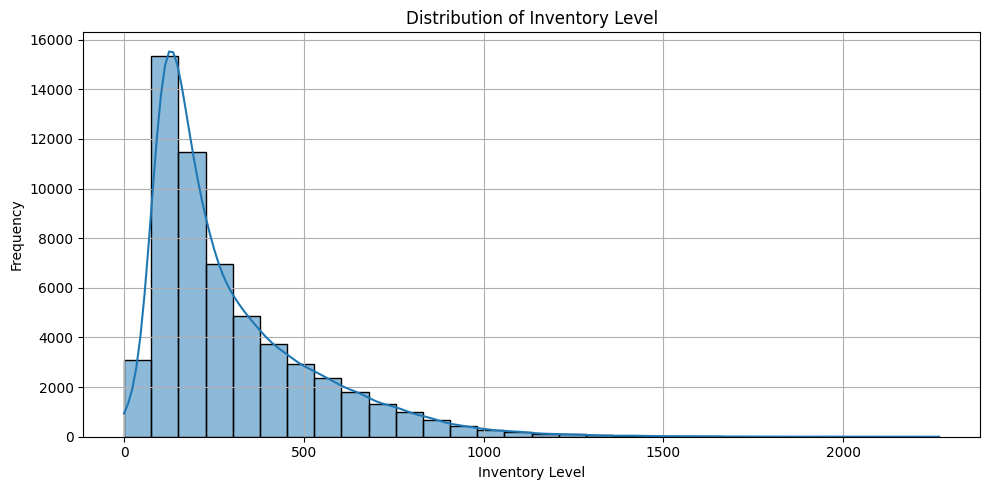

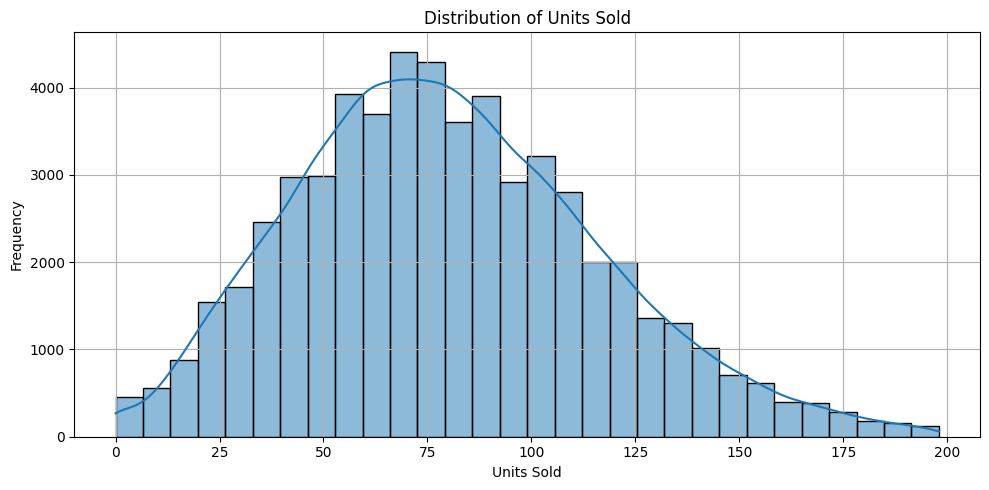

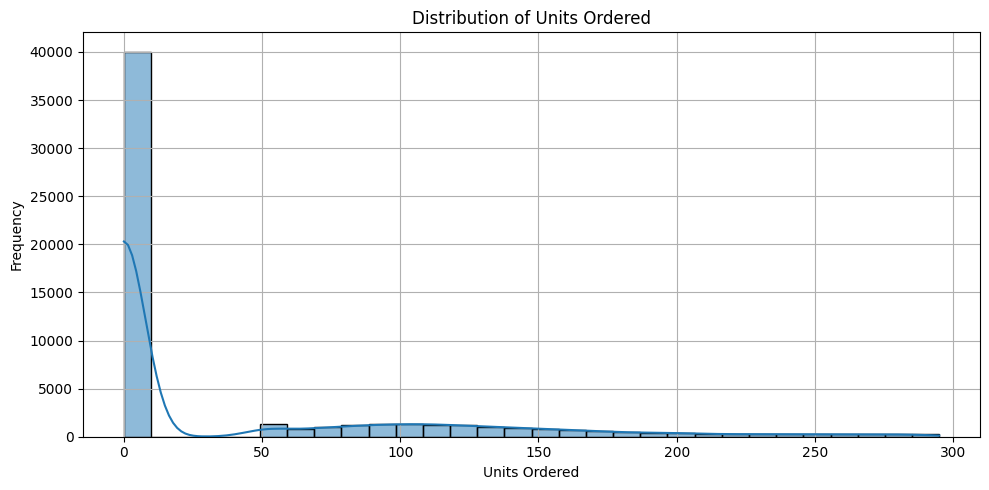

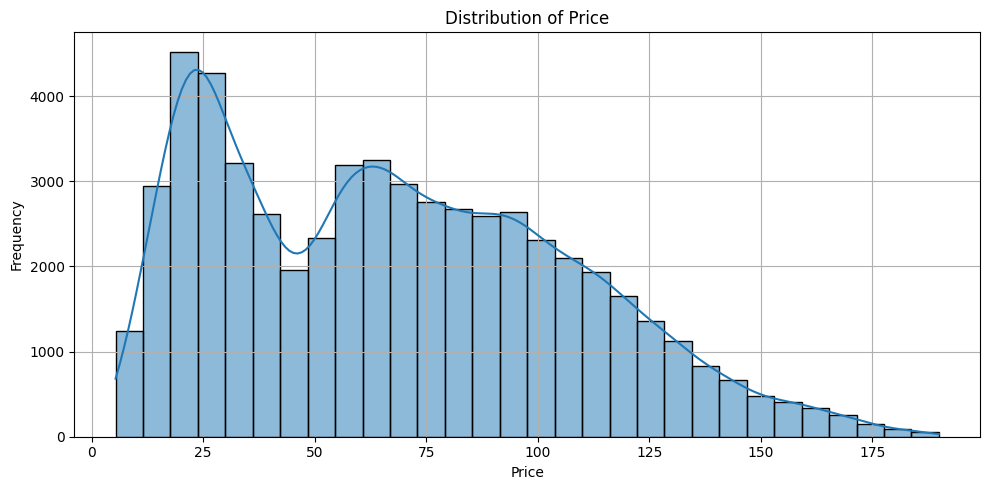

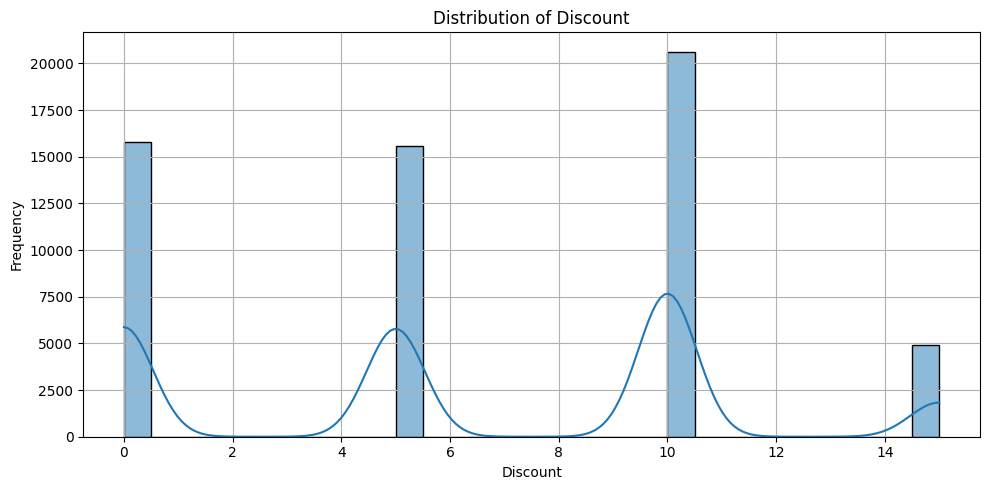

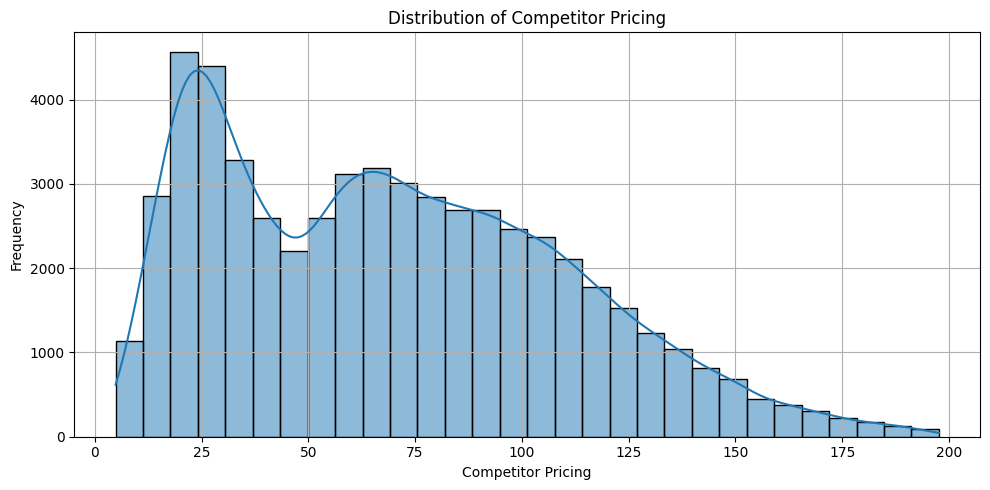

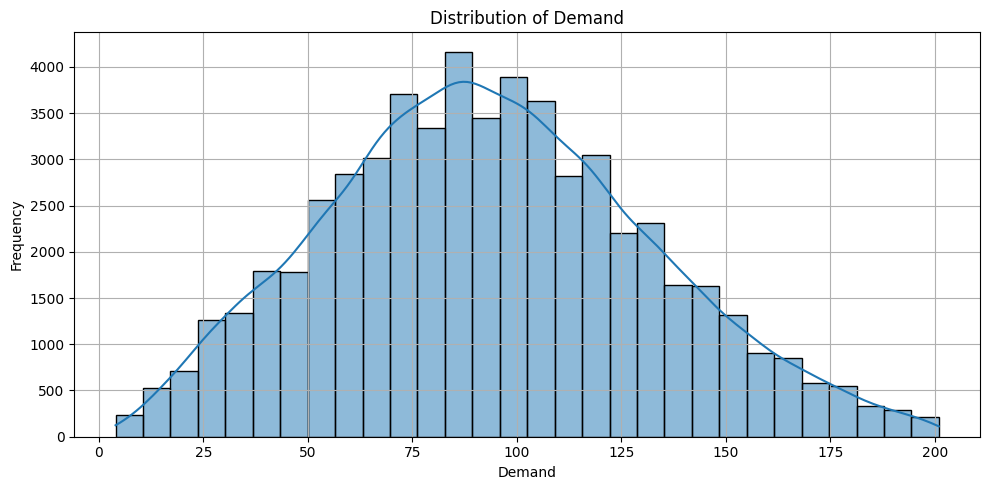

In [18]:
numerical_features = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 
                      'Discount', 'Competitor Pricing', 'Demand']

for col in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_encoded[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Distribution of categorical features

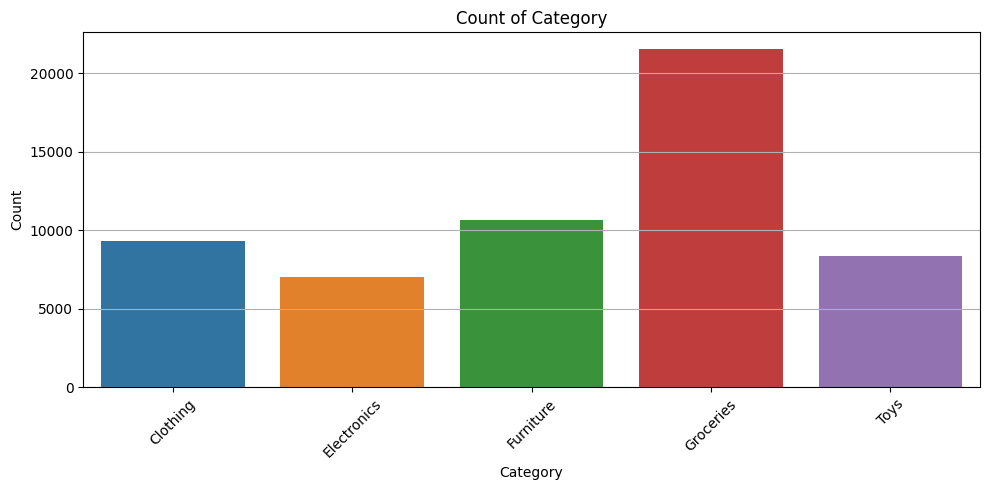

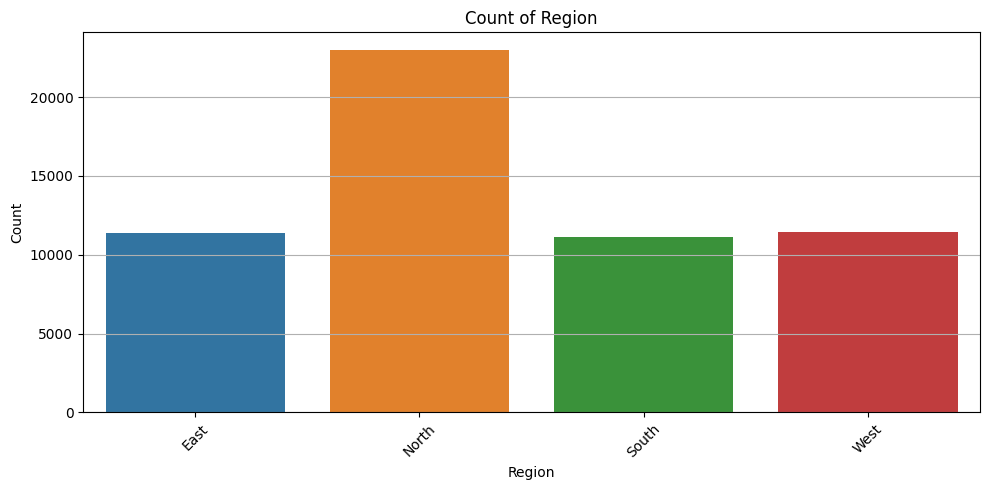

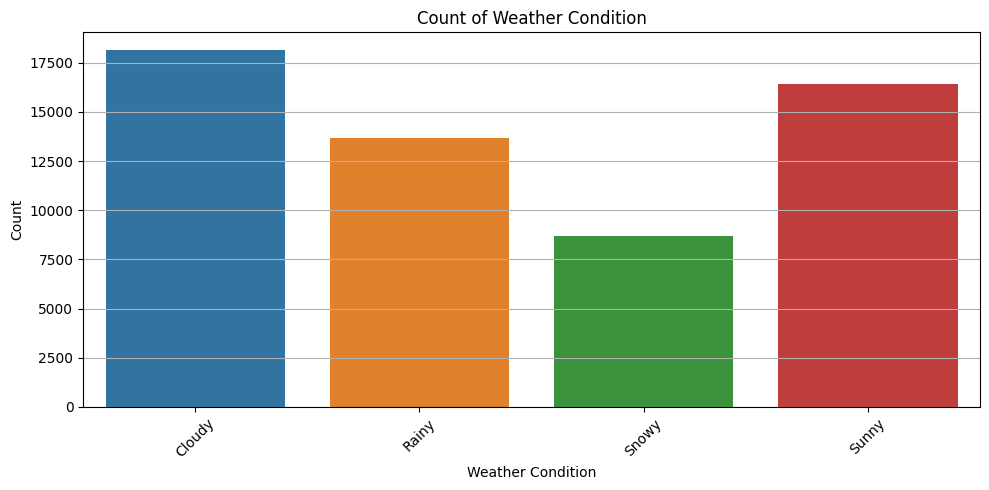

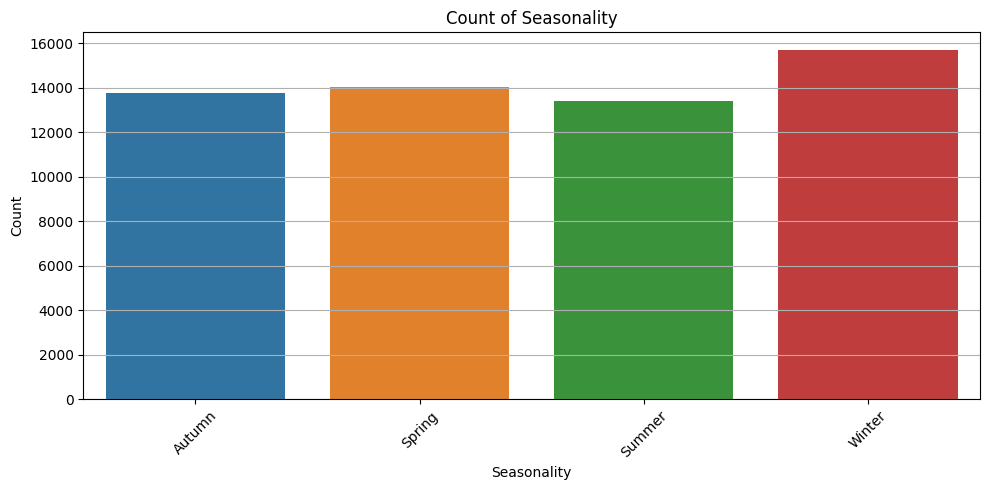

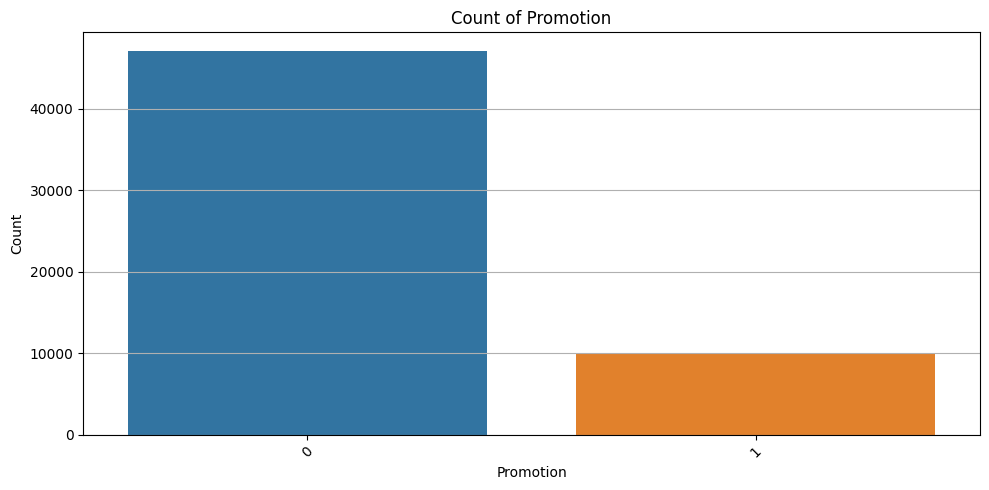

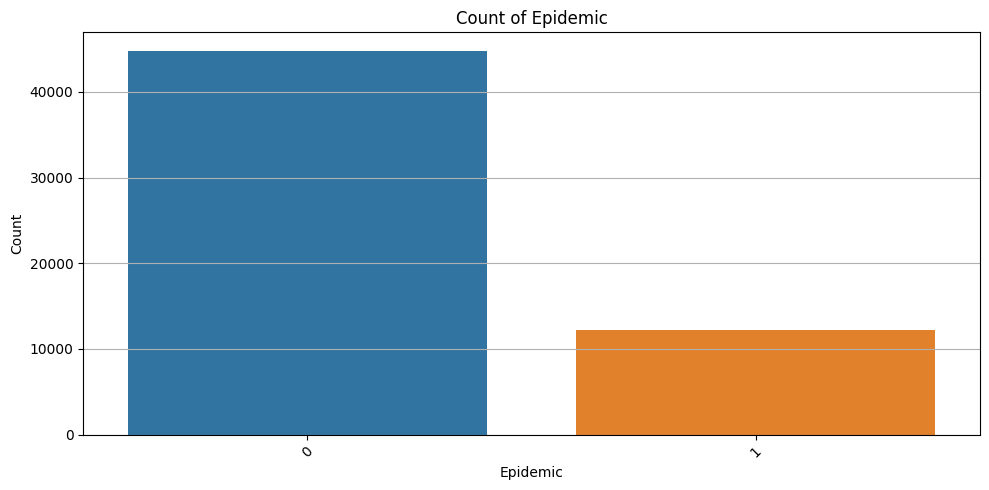

In [19]:
categorical_features = ['Category', 'Region', 'Weather Condition', 'Seasonality', 'Promotion', 'Epidemic']

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=df[col])
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


## Correlation matrix

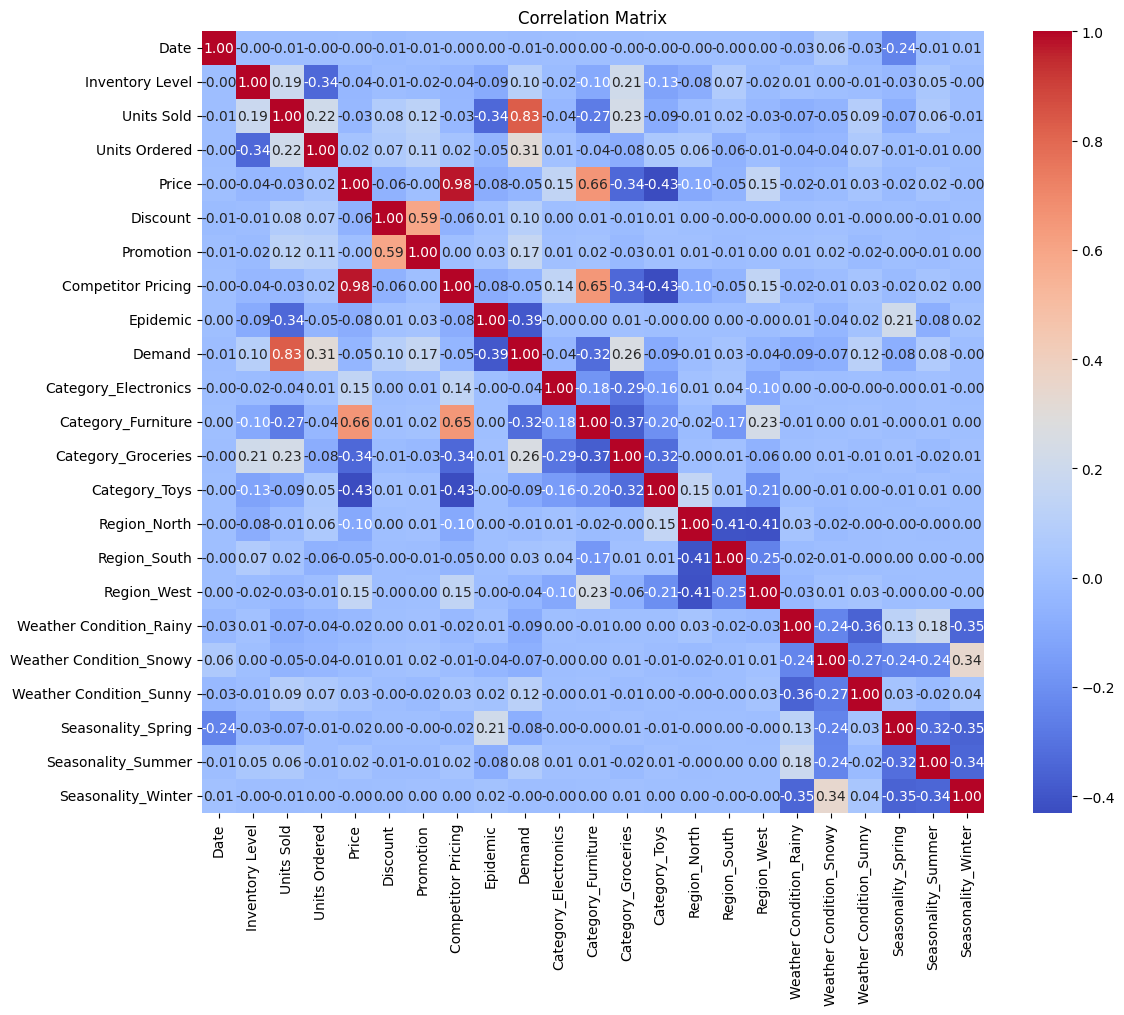

In [20]:
plt.figure(figsize=(12, 10))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Boxplots of target variable vs categorical features

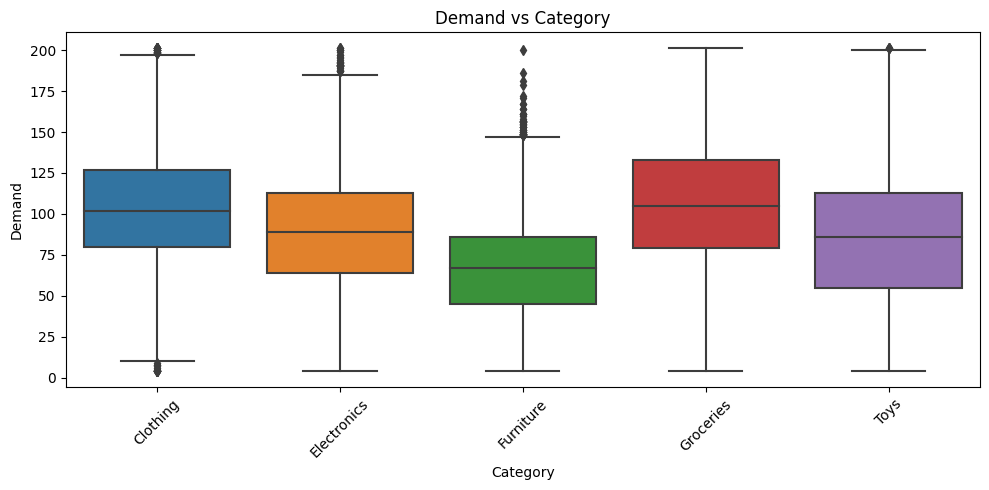

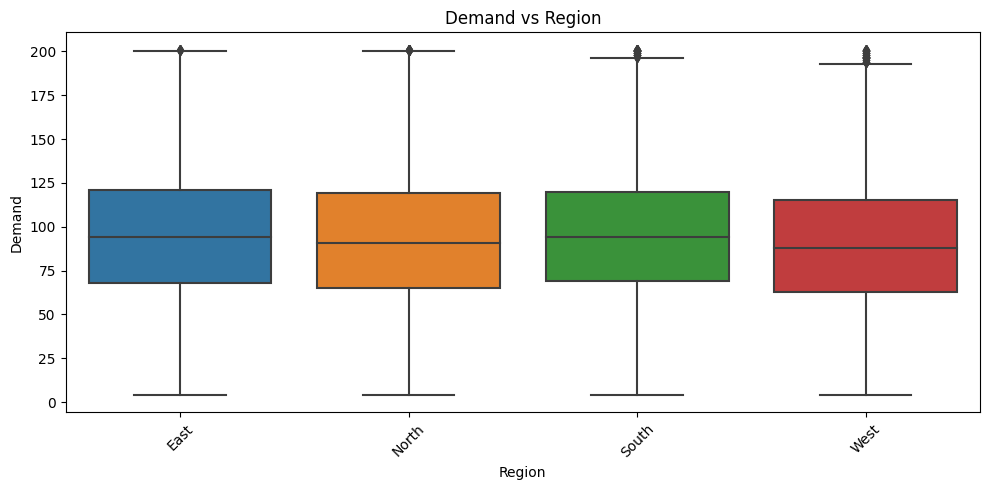

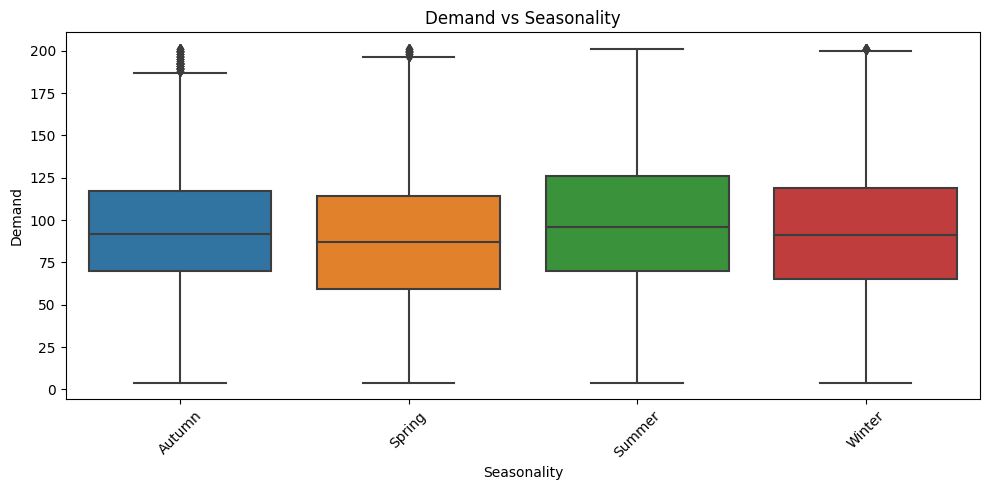

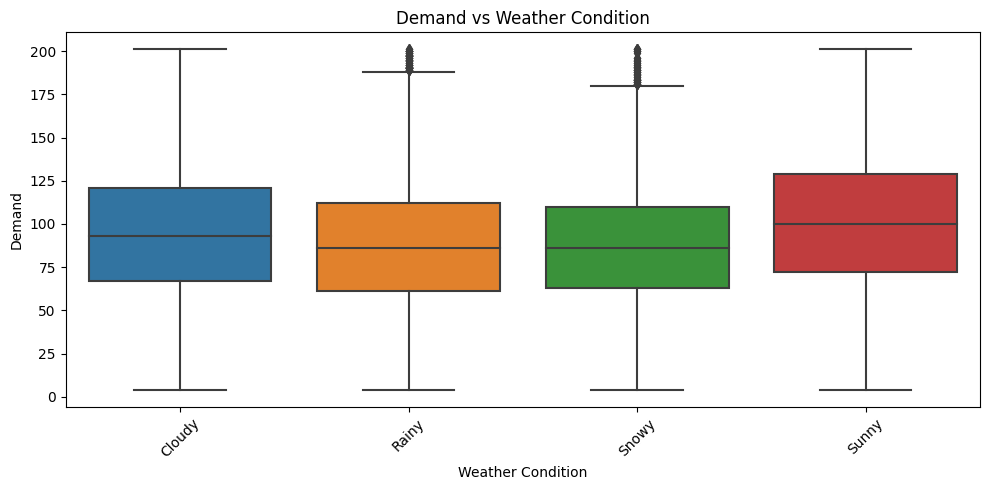

In [21]:
for col in ['Category', 'Region', 'Seasonality', 'Weather Condition']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col], y=df['Demand'])
    plt.title(f"Demand vs {col}")
    plt.xlabel(col)
    plt.ylabel("Demand")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Multicollinearity check using VIF

In [22]:
# Drop Demand (target) and Date column from VIF input
X_for_vif = df_encoded.drop(columns=["Demand"])

# Also drop Date column if it's present
if 'Date' in X_for_vif.columns:
    X_for_vif = X_for_vif.drop(columns=["Date"])

# Ensure all columns are float type
X_vif_ready = X_for_vif.select_dtypes(include=['int64', 'float64']).astype(float)

# Add constant for statsmodels
X_vif_ready = add_constant(X_vif_ready)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_ready.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_ready.values, i) for i in range(X_vif_ready.shape[1])]
vif_data = vif_data[vif_data["Feature"] != "const"]

# Display sorted VIF
print("\n VIF Scores (Multicollinearity Check):")
print(vif_data.sort_values(by="VIF", ascending=False))


 VIF Scores (Multicollinearity Check):
              Feature        VIF
4               Price  21.518513
7  Competitor Pricing  21.509167
6           Promotion   1.574549
5            Discount   1.551707
2          Units Sold   1.291749
3       Units Ordered   1.252607
1     Inventory Level   1.231836
8            Epidemic   1.147806


# Feature Engineering

## New feature creation

In [23]:
df['Sold_Percent'] = df['Units Sold'] / (df['Units Ordered'] + 1e-5)  # To avoid division by zero
df['Revenue'] = df['Units Sold'] * df['Price']
df['Is_Discounted'] = np.where(df['Discount'] > 0, 1, 0)
df['Stock_Change'] = df['Inventory Level'] - df['Units Sold']

## Feature selection using RFE

In [24]:
# One-hot encode
df_encoded = pd.get_dummies(df.drop(columns=["Date"]), drop_first=True)

# Drop target and object type features
X = df_encoded.drop(columns=["Demand"])
y = df_encoded['Demand']

# Fit the model
model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=537, n_jobs=-1)
model.fit(X, y)

# Get top 10 important features
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]
top_features = X.columns[indices]


## Feature Importance Plot

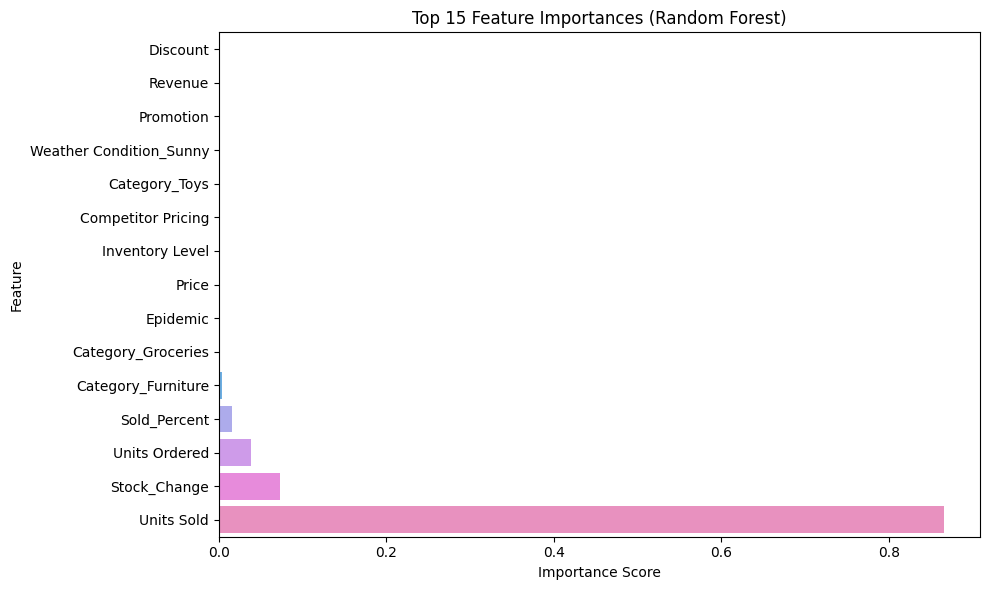

In [25]:
model.fit(X, y)
importances = model.feature_importances_
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 6))
plt.title("Top 15 Feature Importances (Random Forest)")
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## PCA

In [26]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

print(f"\n PCA reduced feature count: {X_pca.shape[1]} components")


 PCA reduced feature count: 1 components


# Data Preparation

## Use top 10 features

In [27]:
X_selected = X[top_features]
y_selected = y


## Train/Test split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_selected, test_size=0.25, random_state=537
)
print(" Train shape:", X_train.shape)
print(" Test shape:", X_test.shape)

 Train shape: (42689, 10)
 Test shape: (14230, 10)


## Scaling

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regression Modeling

## Model Training

In [30]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=537, n_jobs=1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=537, n_jobs=1)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

## Evaluation Function

In [31]:
def evaluate(name, y_true, y_pred):
    print(f"\n {name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²  :", r2_score(y_true, y_pred))
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.4)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name} | Actual vs Predicted")
    plt.tight_layout()
    plt.show()

##  Evaluate all


 Linear Regression
MAE : 14.61359401148085
RMSE: 19.36603687561224
R²  : 0.7434000592106202


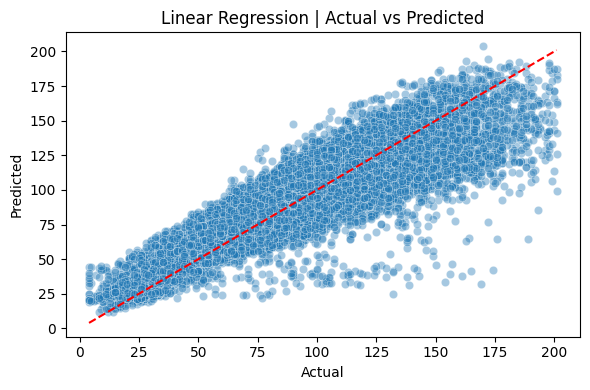


 Random Forest
MAE : 11.800092059030218
RMSE: 15.591932437637272
R²  : 0.8336683363464377


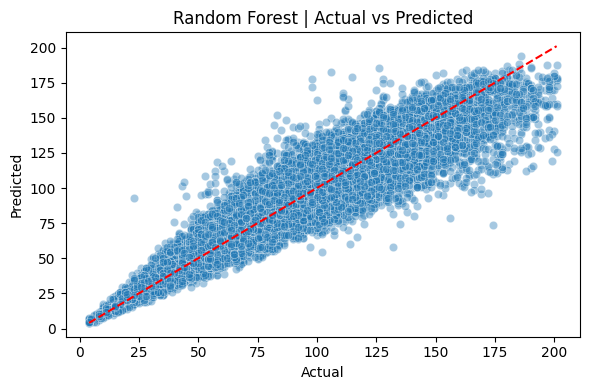


 XGBoost
MAE : 11.645120653064001
RMSE: 15.062758146661995
R²  : 0.8447670006671266


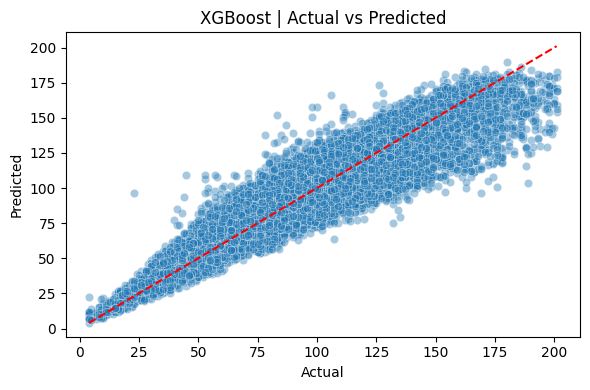

In [32]:
evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("XGBoost", y_test, y_pred_xgb)

#  Deep Learning Model (MLP) for Regression

## MLP Model

In [33]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)  
])
# Compile Model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
# Train Model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=1
)

# Predictions
y_pred_dl = model.predict(X_test_scaled).flatten()


Epoch 1/50


2025-06-02 23:30:01.143812: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


534/534 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4357.5132 - mae: 50.4584 - val_loss: 378.3374 - val_mae: 15.0727
Epoch 2/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 503.7984 - mae: 17.3110 - val_loss: 346.1054 - val_mae: 14.2685
Epoch 3/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 481.5721 - mae: 16.8591 - val_loss: 335.1013 - val_mae: 14.0569
Epoch 4/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 453.9733 - mae: 16.3932 - val_loss: 331.7516 - val_mae: 14.0308
Epoch 5/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 456.3633 - mae: 16.4083 - val_loss: 329.4804 - val_mae: 13.7797
Epoch 6/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 445.8989 - mae: 16.1567 - val_loss: 314.4075 - val_mae: 13.7150
Epoch 7/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 435.8174 - mae: 16.0399 - val_loss: 308.0665 - val_mae: 13.6028
Epoch 8/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 439.3586 - mae: 15.9669 - val_loss: 303.8786 - val_mae: 13.5151
Epoch 9/50
534/534

## Evaluation

In [34]:
print(" Deep Learning (MLP) Results:")
print("MAE :", mean_absolute_error(y_test, y_pred_dl))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dl)))
print("R²  :", r2_score(y_test, y_pred_dl))


 Deep Learning (MLP) Results:
MAE : 12.097932071109431
RMSE: 15.69399861946098
R²  : 0.8314835649793607


## Plot Actual vs Predicted

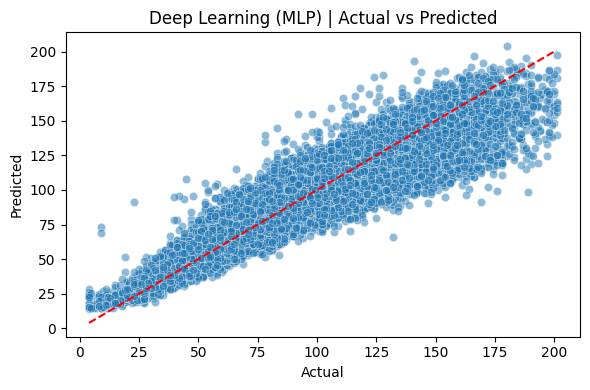

In [35]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred_dl, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Deep Learning (MLP) | Actual vs Predicted")
plt.tight_layout()
plt.show()

##  Plot Loss & MAE

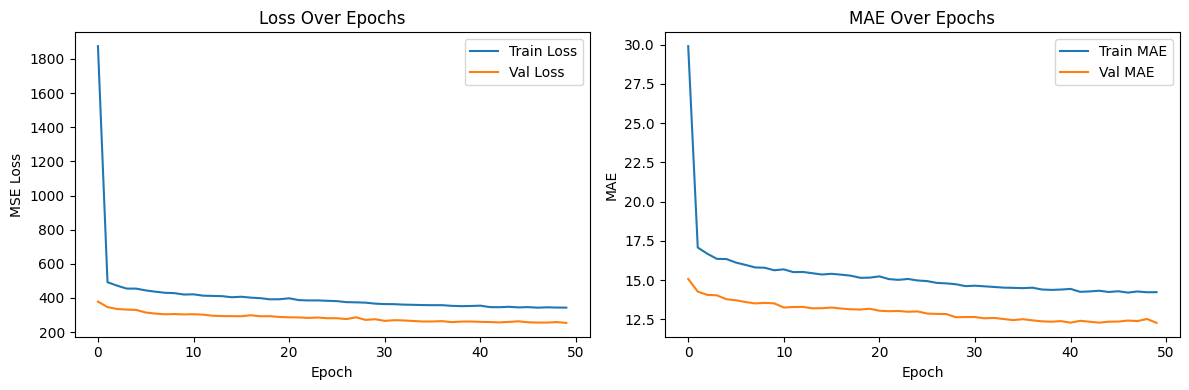

In [36]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title("MAE Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

---

#  SALES DEMAND PREDICTION PROJECT – SUMMARY


---

###  1. Import Libraries

Essential libraries were imported for:

* Data manipulation: `pandas`, `numpy`
* Visualization: `matplotlib`, `seaborn`
* Modeling: `sklearn`, `xgboost`, `tensorflow`

---

###  2. Data Access and First Look

* Loaded the CSV into a DataFrame.
* Reviewed structure with `.info()` and `.describe()`.
* Checked for missing values (none critical).
* Verified target variable (`Demand`) distribution.
* Built a **data dictionary** to document all variables.

---

###  3. Data Cleaning and Transformation

* Filled any NaNs with mean/median as appropriate.
* Removed irrelevant identifiers: `Store ID`, `Product ID`, `Date`.
* Converted booleans and categoricals using `pd.get_dummies`.
* Ensured all features were numeric for modeling.

---

###  4. Exploratory Data Analysis (EDA)

* Visualized distributions of numeric features (histogram, KDE).
* Countplots for categorical variables.
* Heatmap for correlation matrix.
* Violin and boxplots for Demand across different categories.
* Multicollinearity checked using VIF.

---

###  5. Feature Engineering

* Created new features:

  * `Sold_Percent`: Units Sold / Units Ordered
  * `Revenue`: Units Sold × Price
  * `Is_Discounted`: Binary flag
  * `Stock_Change`: Inventory Level – Units Sold
* Feature selection with `RFE` and `RandomForestRegressor`.
* Visualized top 15 features using barplot.
* PCA used optionally for dimensionality reduction.

---

###  6. Data Preparation

* Splitted data: 75% training, 25% testing.
* Scaled features using `StandardScaler`.
* Target variable left as is (no transformation).
* Stratification not needed (regression task).

---

###  7. Machine Learning Models

Trained and evaluated the following models:

*  Linear Regression
*  Random Forest Regressor
*  XGBoost Regressor

**Evaluation Metrics Used:**

* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* R² Score (R-Squared)

---

###  8. Deep Learning Model

Built a **Multilayer Perceptron (MLP)** with:

* Input layer → Dense(128, ReLU) + Dropout(0.3)
* Hidden layer → Dense(64, ReLU) + Dropout(0.2)
* Output layer → Dense(1, linear)

**Compiled with:**

* Loss: Mean Squared Error
* Optimizer: Adam (lr=0.001)
* Epochs: 50
* Batch Size: 64

**Visualized:**

* Loss and MAE curves
* Actual vs Predicted scatterplot

---

# Thank you for taking the time to review my work. I would be very happy if you could upvote! 😊

---


